In [4]:
import glob
dtl_files = glob.glob("../data/output_data/tsc/sumo_*/sumo_cologne3/repro_3600/logger/*_DTL.log")
print(len(dtl_files), "files")
for p in dtl_files: print(p)

3 files
../data/output_data/tsc/sumo_colight/sumo_cologne3/repro_3600/logger/2026_06_21-11_51_33_DTL.log
../data/output_data/tsc/sumo_presslight/sumo_cologne3/repro_3600/logger/2026_06_21-11_51_34_DTL.log
../data/output_data/tsc/sumo_mplight/sumo_cologne3/repro_3600/logger/2026_06_21-11_51_33_DTL.log


# Cologne 1×3 Reproduction — Value-Based Models

**Run:** `repro_3600` · 200 episodes · 3600s · seed 42 · SUMO/libsumo
**Models:** PressLight, MPLight, CoLight (+ MaxPressure baseline = 60.1)
**Metric:** real average travel time (lower = better). Convention for the table: **best test episode** (matches LibSignal).

Two questions:
1. **Did training go healthy?** — per-episode train/test curves (descend + plateau, test cleaner than train).
2. **What are the final numbers?** — best & final test travel time vs the paper.

In [10]:
import pandas as pd, glob

cols = ["model","split","episode","travel_time","col5","reward","queue","delay","throughput"]
paths = glob.glob("../data/output_data/tsc/sumo_*/sumo_cologne3/repro_3600/logger/*_DTL.log")

dfs = {}
for p in paths:
    name = p.split("sumo_")[1].split("/")[0]
    df = pd.read_csv(p, sep="\t", header=None, names=cols)
    dfs[name] = df

# split train vs test into separate frames per model
train = {n: d[d.split=="TRAIN"].reset_index(drop=True) for n,d in dfs.items()}
test  = {n: d[d.split=="TEST"].reset_index(drop=True)  for n,d in dfs.items()}

for n in dfs:
    print(n, "train rows:", len(train[n]), "test rows:", len(test[n]))
test["colight"][["episode","travel_time","throughput"]].head()

colight train rows: 200 test rows: 200
presslight train rows: 200 test rows: 200
mplight train rows: 200 test rows: 200


,episode,travel_time,throughput
0,0,837.9,450
1,1,837.9,450
2,2,837.9,450
3,3,268.0,1483
4,4,268.0,1483


## 1. Training curves (train vs test per episode)
Healthy = both descend then plateau; **test smoother than train** (exploration noise lives in train only).

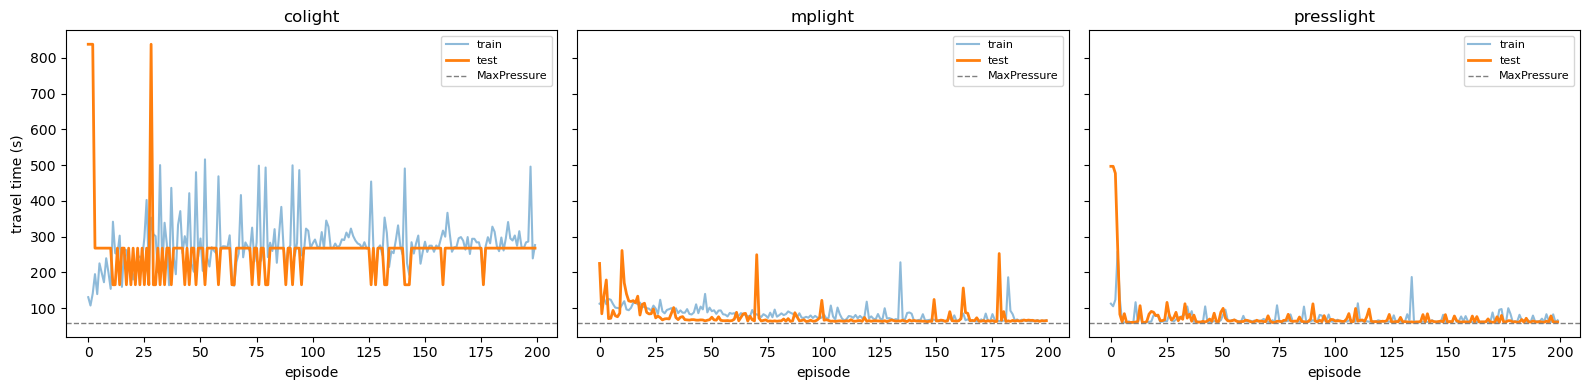

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16,4), sharey=True)
for ax,(name,_) in zip(axes, sorted(dfs.items())):
    ax.plot(train[name].episode, train[name].travel_time, alpha=.5, label="train")
    ax.plot(test[name].episode,  test[name].travel_time,  lw=2,   label="test")
    ax.axhline(60.1, ls="--", c="gray", lw=1, label="MaxPressure")
    ax.set_title(name); ax.set_xlabel("episode"); ax.legend(fontsize=8)
axes[0].set_ylabel("travel time (s)")
plt.tight_layout(); plt.show()

## 2. Final results table (best & final test travel time)
Best-episode = LibSignal convention. Paper refs: PressLight ~77 · MPLight ~96 (note: our MPLight is a fork variant) · CoLight (no cologne3 paper row).

In [16]:
import pandas as pd

# Paper Table 8, SUMO, Cologne 1x3 (travel time, seconds)
paper = {"maxpressure": 74.22, "presslight": 71.00, "mplight": 91.91, "colight": None}

rows = []
for name in sorted(test):                    # test = your TEST-split dict
    t = test[name]
    rows.append({
        "model": name,
        "ours_best":  round(t.travel_time.min(), 2),
        "ours_final": round(t.travel_time.iloc[-1], 2),
        "paper_sumo": paper.get(name),
    })
summary = pd.DataFrame(rows)
summary.loc[len(summary)] = ["maxpressure", 60.10, 60.10, 74.22]

summary["diff_vs_paper_%"] = summary.apply(
    lambda r: round(100*(r.ours_best - r.paper_sumo)/r.paper_sumo, 1)
              if pd.notnull(r.paper_sumo) else None, axis=1)

notes = {"colight": "NOT in paper for cologne1x3; did not converge",
         "mplight": "fork variant (ob_length/self.training)"}
summary["note"] = summary.model.map(notes).fillna("")
summary

,model,ours_best,ours_final,paper_sumo,diff_vs_paper_%,note
0,colight,165.6,268.0,NaN,NaN,NOT in paper for cologne1x3; did not converge
1,mplight,62.3,65.3,91.91,-32.2,fork variant (ob_length/self.training)
2,presslight,59.7,61.6,71.00,-15.9,
3,maxpressure,60.1,60.1,74.22,-19.0,


## Deterministic Baseline Reproduction: Version × Network

Deterministic baselines (no learning, no randomness) used as environment probes.
Identical inputs → identical outputs, so any gap vs. paper isolates an
environment/config difference rather than agent variance.

| Network      | Agent        | Ours (SUMO 1.26) | Ours (SUMO 1.15) | Paper (SUMO)  | Match? |
|--------------|--------------|-----------------:|-----------------:|--------------:|:------:|
| Cologne 1×3  | MaxPressure  | 60.10            | 61.78            | 74.22         | ✗ (~19% low) |
| Cologne 1×3  | FixedTime    | 80.00            | 79.76            | 153.02 (t=30) | ✗ (~48% low) |
| Grid 4×4     | MaxPressure  | 155.39           | 155.30           | 154.15        | ✓ (~1%) |
| Grid 4×4     | FixedTime    | 226.74           | 227.26           | 222.13 (t=10) | ✓ (~2%) |

### Findings
1. **SUMO version is irrelevant.** Across both networks, 1.26 vs 1.15 differ
   by <2s (Cologne MP 60.1/61.8, FT 80.0/79.8; Grid MP 155.4/155.3,
   FT 226.7/227.3). The version is fully ruled out as a cause.
2. **Grid 4×4 reproduces the paper** on both SUMO versions
   (MaxPressure ~155 vs 154.2; FixedTime ~227 vs 222.1). Pipeline, world
   code, and measurement are validated.
3. **The discrepancy is Cologne-1×3-specific.** Identical code/version
   reproduces Grid but not Cologne → the cause is localized to the
   Cologne 1×3 dataset (network/flow files or `.sumocfg`), not a global
   environment difference.

🟥 Note: Cologne network was rebuilt with netconvert (--junctions.limit-turn-speed 5.5, --no-turnarounds, see cologne3/README.md) and ships two demand variants — the paper's exact Cologne setup is unverified, so the gap may stem from a dataset difference, not our run.

# Grid 4×4 Reproduction — Value-Based Models

**Run:** `grid_repro` · 200 episodes · 3600s · seed 42 · SUMO 1.26
**Models:** PressLight, MPLight, CoLight (+ MaxPressure 155.4, FixedTime 226.7 baselines)
**Metric:** real avg travel time (lower = better). Table uses **best test episode** (LibSignal convention).

**Paper Grid4×4 SUMO targets (Table 8):** MaxPressure 154.15 · FixedTime 222.13 · PressLight 152.81 · MPLight 147.19 · CoLight 154.10

Key question vs. Cologne: does CoLight — which thrashed on the 3-node corridor —
**converge on the 32-node grid** it was designed for? (Topology-dependence test.)

In [1]:
import pandas as pd, glob

cols = ["model","split","episode","travel_time","col5","reward","queue","delay","throughput"]
paths = glob.glob("../data/output_data/tsc/sumo_*/sumo4x4/grid_repro/logger/*_DTL.log")
print(len(paths), "files:", paths)

dfs = {}
for p in paths:
    name = p.split("sumo_")[1].split("/")[0]
    dfs[name] = pd.read_csv(p, sep="\t", header=None, names=cols)

train = {n: d[d.split=="TRAIN"].reset_index(drop=True) for n,d in dfs.items()}
test  = {n: d[d.split=="TEST"].reset_index(drop=True)  for n,d in dfs.items()}
for n in dfs: print(n, "train:", len(train[n]), "test:", len(test[n]))

4 files: ['../data/output_data/tsc/sumo_colight/sumo4x4/grid_repro/logger/2026_06_24-08_28_37_DTL.log', '../data/output_data/tsc/sumo_presslight/sumo4x4/grid_repro/logger/2026_06_24-08_28_39_DTL.log', '../data/output_data/tsc/sumo_mplight/sumo4x4/grid_repro/logger/2026_06_24-08_27_05_DTL.log', '../data/output_data/tsc/sumo_mplight/sumo4x4/grid_repro/logger/2026_06_24-08_28_39_DTL.log']
colight train: 200 test: 200
presslight train: 200 test: 200
mplight train: 200 test: 200


## 1. Training curves (train vs test per episode)
Grid4×4 SUMO. Dashed line = paper target per model. Healthy = descend then plateau near the paper line.

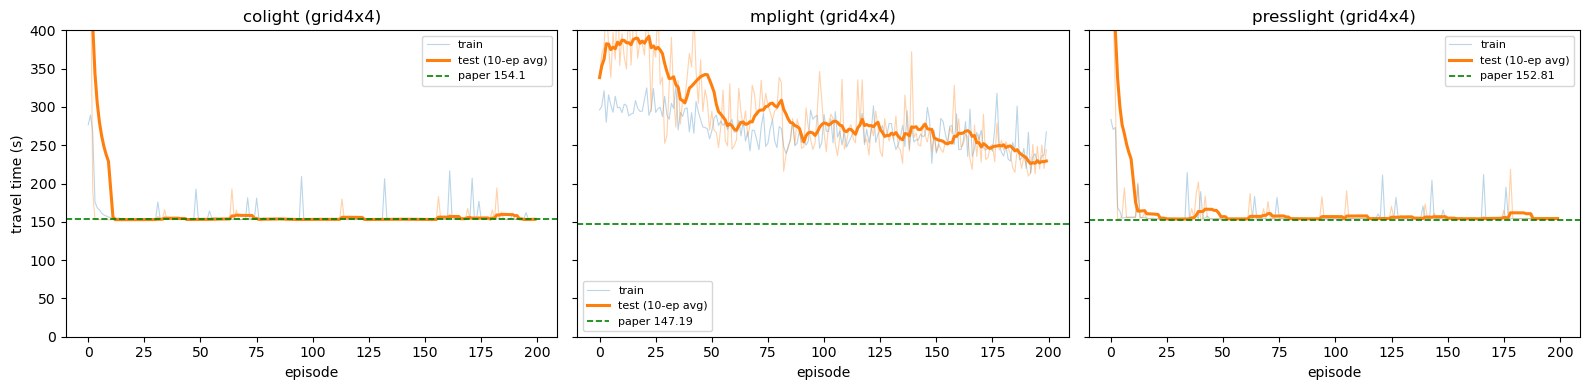

In [2]:
import matplotlib.pyplot as plt

paper = {"presslight":152.81, "mplight":147.19, "colight":154.10}

fig, axes = plt.subplots(1, 3, figsize=(16,4), sharey=True)
for ax,(name,_) in zip(axes, sorted(dfs.items())):
    t = test[name]
    ax.plot(train[name].episode, train[name].travel_time, alpha=.3, lw=.8, label="train")
    ax.plot(t.episode, t.travel_time, alpha=.35, lw=.8, color="C1")
    ax.plot(t.episode, t.travel_time.rolling(10, min_periods=1).mean(),
            lw=2.2, color="C1", label="test (10-ep avg)")
    if name in paper:
        ax.axhline(paper[name], ls="--", c="green", lw=1.2, label=f"paper {paper[name]}")
    ax.set_title(f"{name} (grid4x4)"); ax.set_xlabel("episode"); ax.legend(fontsize=8)
axes[0].set_ylim(0, 400)          # cap so plateau detail is visible
axes[0].set_ylabel("travel time (s)")
plt.tight_layout(); plt.show()

## 2. Reproduction table — best-episode test travel time vs paper

In [3]:
paper_all = {"maxpressure":154.15, "fixedtime":222.13,
             "presslight":152.81, "mplight":147.19, "colight":154.10}

rows=[]
for name in sorted(test):
    t = test[name]
    best = t.travel_time.min()
    rows.append({"model":name,
                 "ours_best": round(best,2),
                 "ours_final": round(t.travel_time.iloc[-1],2),
                 "best_ep": int(t.loc[t.travel_time.idxmin(),"episode"]),
                 "paper": paper_all.get(name)})
summary = pd.DataFrame(rows)
# add deterministic baselines you already have
summary.loc[len(summary)] = ["maxpressure",155.39,155.39,"-",154.15]
summary.loc[len(summary)] = ["fixedtime",226.74,226.74,"-",222.13]
summary["diff_%"] = summary.apply(
    lambda r: round(100*(r.ours_best-r.paper)/r.paper,1) if pd.notnull(r.paper) else None, axis=1)
summary.sort_values("model")

,model,ours_best,ours_final,best_ep,paper,diff_%
0,colight,152.70,154.10,6,154.10,-0.9
4,fixedtime,226.74,226.74,-,222.13,2.1
3,maxpressure,155.39,155.39,-,154.15,0.8
1,mplight,209.70,244.20,191,147.19,42.5
2,presslight,153.40,154.20,21,152.81,0.4


### so 4/5 above have successfully reproduced 

I will re run the mplight with 500 episodes to see if it would converge

200-ep file: 2026_06_24-08_28_39_DTL.log → max ep 199
500-ep file: 2026_06_25-10_12_57_DTL.log → max ep 499


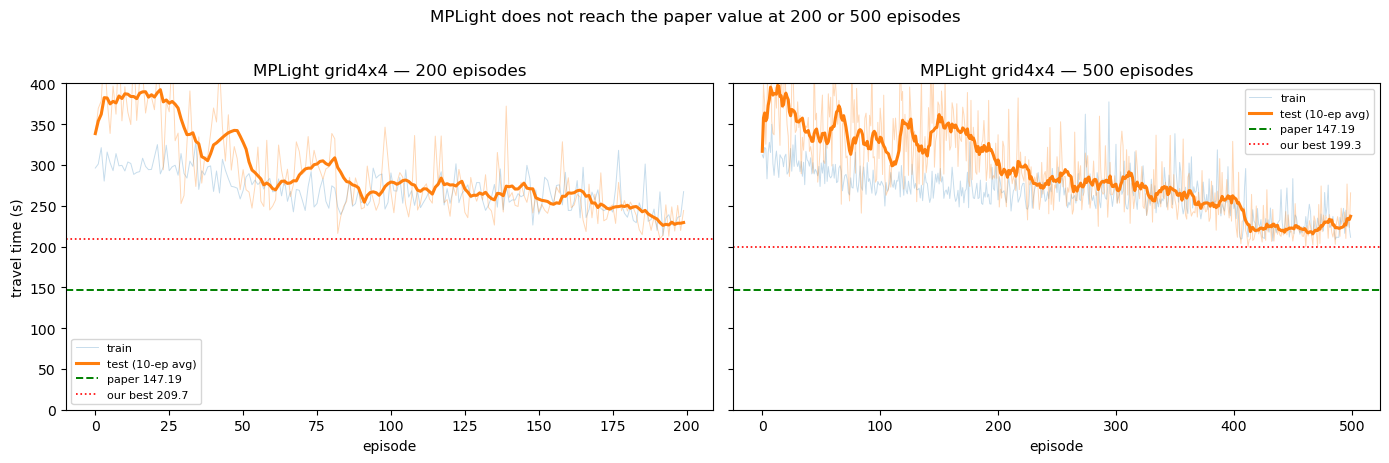

In [2]:
import glob, pandas as pd, matplotlib.pyplot as plt

cols = ["model","split","episode","travel_time","col5","reward","queue","delay","throughput"]

def load_best(folder_glob):
    """Pick the DTL log with the most episodes (the real full run, not a smoke test)."""
    paths = glob.glob(folder_glob)
    best_p, best_max = None, -1
    for p in paths:
        d = pd.read_csv(p, sep="\t", header=None, names=cols)
        if d.episode.max() > best_max:
            best_p, best_max = p, d.episode.max()
    d = pd.read_csv(best_p, sep="\t", header=None, names=cols)
    return d[d.split=="TRAIN"].reset_index(drop=True), d[d.split=="TEST"].reset_index(drop=True), best_p

tr200, te200, p200 = load_best("../data/output_data/tsc/sumo_mplight/sumo4x4/grid_repro/logger/*_DTL.log")
tr500, te500, p500 = load_best("../data/output_data/tsc/sumo_mplight/sumo4x4/grid_repro_500/logger/*_DTL.log")
print("200-ep file:", p200.split('/')[-1], "→ max ep", te200.episode.max())
print("500-ep file:", p500.split('/')[-1], "→ max ep", te500.episode.max())

fig, axes = plt.subplots(1, 2, figsize=(14,4.5), sharey=True)
for ax, (tr, te, title) in zip(axes, [
        (tr200, te200, "MPLight grid4x4 — 200 episodes"),
        (tr500, te500, "MPLight grid4x4 — 500 episodes")]):
    ax.plot(tr.episode, tr.travel_time, alpha=.25, lw=.7, color="C0", label="train")
    ax.plot(te.episode, te.travel_time, alpha=.3, lw=.7, color="C1")
    ax.plot(te.episode, te.travel_time.rolling(10, min_periods=1).mean(),
            lw=2.2, color="C1", label="test (10-ep avg)")
    ax.axhline(147.19, ls="--", c="green", lw=1.4, label="paper 147.19")
    ax.axhline(round(te.travel_time.min(),1), ls=":", c="red", lw=1.2,
               label=f"our best {round(te.travel_time.min(),1)}")
    ax.set_title(title); ax.set_xlabel("episode"); ax.legend(fontsize=8)
axes[0].set_ylim(0, 400); axes[0].set_ylabel("travel time (s)")
plt.suptitle("MPLight does not reach the paper value at 200 or 500 episodes", y=1.02)
plt.tight_layout(); plt.show()

## Actor critic Models (MAPG, IPPO) 

MAGD: 636 train / 636 test rows, max ep 635, best test 188.1
IPPO: 1130 train / 1130 test rows, max ep 1129, best test 180.2


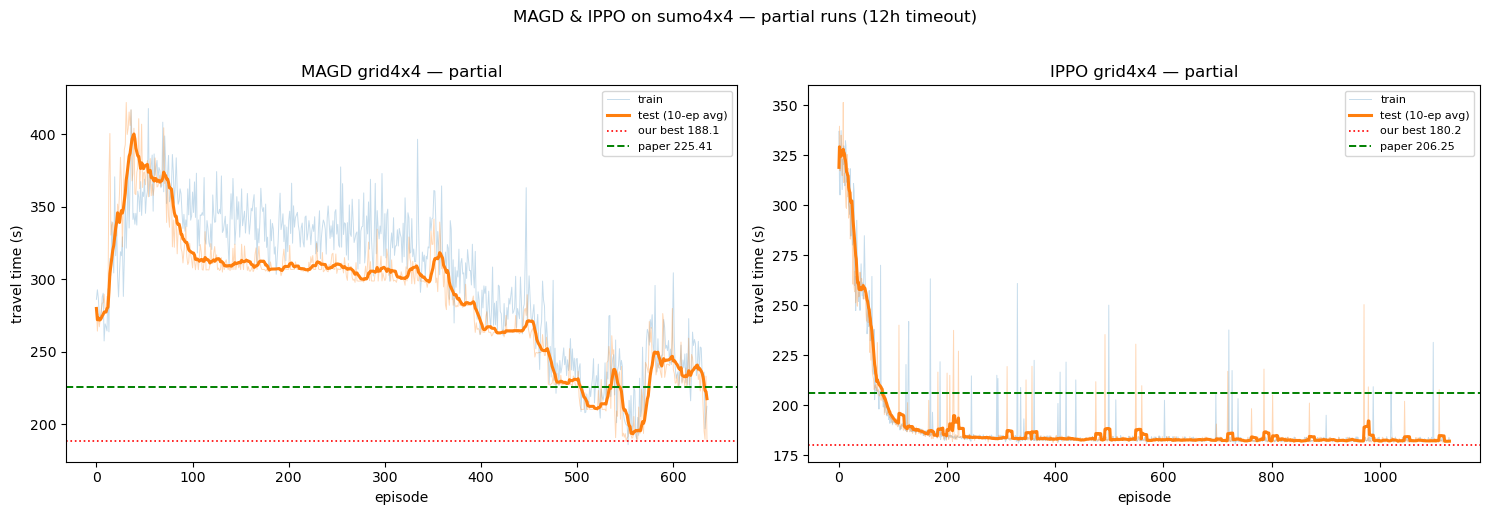

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

BASE = "/Users/ziyodjanmirzataev/Desktop/LibSignalFork/data/output_data/tsc"

RUNS = {
    "MAGD": f"{BASE}/sumo_magd/sumo4x4/magd_4x4_run1/logger/2026_06_24-16_00_03_DTL.log",
    "IPPO": f"{BASE}/sumo_ppo_pfrl/sumo4x4/ippo_4x4_run1/logger/2026_06_24-16_01_07_DTL.log",
}
PAPER = {"MAGD": 225.41, "IPPO": 206.25}

def parse(path):
    train, test = [], []
    with open(path) as f:
        for line in f:
            p = line.strip().split("\t")
            if len(p) < 4:
                continue
            phase, ep, tt = p[1], p[2], p[3]   # TRAIN/TEST, episode, travel_time
            try:
                ep, tt = int(ep), float(tt)
            except ValueError:
                continue
            (train if phase == "TRAIN" else test).append((ep, tt))
    return (pd.DataFrame(train, columns=["episode", "travel_time"]),
            pd.DataFrame(test,  columns=["episode", "travel_time"]))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (name, path) in zip(axes, RUNS.items()):
    tr, te = parse(path)
    print(f"{name}: {len(tr)} train / {len(te)} test rows, "
          f"max ep {tr.episode.max() if len(tr) else 'NA'}, "
          f"best test {round(te.travel_time.min(),1) if len(te) else 'NA'}")
    if len(tr):
        ax.plot(tr.episode, tr.travel_time, alpha=.25, lw=.7, color="C0", label="train")
    if len(te):
        ax.plot(te.episode, te.travel_time, alpha=.3, lw=.7, color="C1")
        ax.plot(te.episode, te.travel_time.rolling(10, min_periods=1).mean(),
                lw=2.2, color="C1", label="test (10-ep avg)")
        best = round(te.travel_time.min(), 1)
        ax.axhline(best, ls=":", c="red", lw=1.2, label=f"our best {best}")
    ax.axhline(PAPER[name], ls="--", c="green", lw=1.4, label=f"paper {PAPER[name]}")
    ax.set_title(f"{name} grid4x4 — partial"); ax.set_xlabel("episode")
    ax.set_ylabel("travel time (s)"); ax.legend(fontsize=8)

plt.suptitle("MAGD & IPPO on sumo4x4 — partial runs (12h timeout)", y=1.02)
plt.tight_layout(); plt.show()

## in 2 different versions of papers they report very different travel times for these two models

#### For MAPG on Grid4x4/SUMO (average travel time): the 2022 workshop paper reports 225.41, while the 2024 journal paper reports 458.29 — the same authors, same agent, same network, but roughly double the number between versions

## Re-trained the IDQNon 4x4 because that is one of the most promising models in the paper 


file: 2026_06_27-09_30_14_DTL.log → max ep 199


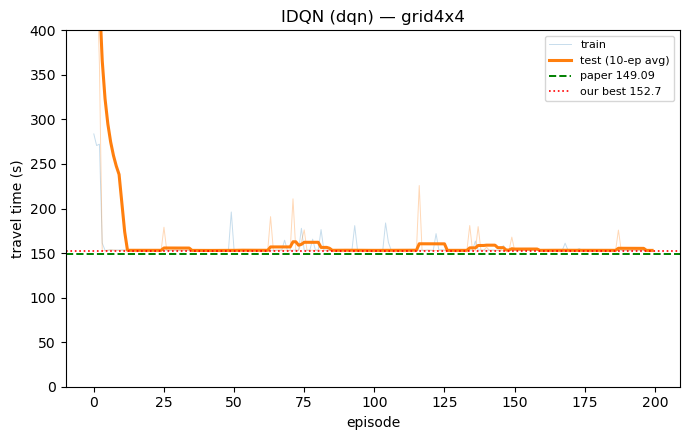

In [7]:
import glob, pandas as pd, matplotlib.pyplot as plt

cols = ["model","split","episode","travel_time","col5","reward","queue","delay","throughput"]
paper_val = 149.09   # IDQN, Grid4x4 SUMO, Table 8

GLOB = "../data/output_data/tsc/sumo_dqn/sumo4x4/dqn_grid4x4_seed42/logger/*_DTL.log"

def load_best(folder_glob):
    paths = glob.glob(folder_glob)
    assert paths, f"no DTL logs matched {folder_glob}"
    best_p, best_max = None, -1
    for p in paths:
        d = pd.read_csv(p, sep="\t", header=None, names=cols)
        if d.episode.max() > best_max:
            best_p, best_max = p, d.episode.max()
    d = pd.read_csv(best_p, sep="\t", header=None, names=cols)
    return d[d.split=="TRAIN"].reset_index(drop=True), d[d.split=="TEST"].reset_index(drop=True), best_p

tr, te, path = load_best(GLOB)
print("file:", path.split('/')[-1], "→ max ep", te.episode.max())

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(tr.episode, tr.travel_time, alpha=.25, lw=.7, color="C0", label="train")
ax.plot(te.episode, te.travel_time, alpha=.3,  lw=.7, color="C1")
ax.plot(te.episode, te.travel_time.rolling(10, min_periods=1).mean(),
        lw=2.2, color="C1", label="test (10-ep avg)")
ax.axhline(paper_val, ls="--", c="green", lw=1.4, label=f"paper {paper_val}")
ax.axhline(round(te.travel_time.min(),1), ls=":", c="red", lw=1.2,
           label=f"our best {round(te.travel_time.min(),1)}")
ax.set_ylim(0, 400)
ax.set_title("IDQN (dqn) — grid4x4"); ax.set_xlabel("episode"); ax.set_ylabel("travel time (s)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [10]:
import pandas as pd

# reproduced best-episode test travel times (Grid4x4, SUMO)
ours = {
    "fixedtime":   226.74,   # deterministic baseline
    "maxpressure": 155.39,   # deterministic baseline
    "dqn":         152.70,   # NEW — IDQN reproduction
    "presslight":  153.40,
    "colight":     152.70,
    "mplight":     209.70,   # fork variant — not a clean comparison
}

# journal Table 8, Grid4x4 / SUMO / travel time (p.5253–5254)
paper = {
    "fixedtime":   222.13,   # t_fixed=10
    "maxpressure": 154.15,
    "dqn":         149.09,   # IDQN
    "presslight":  152.81,
    "colight":     154.10,
    "mplight":     147.19,
}
note = {"mplight": "fork variant (ob_length) — not a reproduction",
        "dqn":     "IDQN — stable anchor, best≈final"}

rows = [{"model": m, "ours": ours[m], "paper": paper[m],
         "diff_%": round(100*(ours[m]-paper[m])/paper[m], 1),
         "note": note.get(m, "")}
        for m in ["fixedtime","maxpressure","dqn","presslight","colight","mplight"]]

summary = pd.DataFrame(rows)
summary

,model,ours,paper,diff_%,note
0,fixedtime,226.74,222.13,2.1,
1,maxpressure,155.39,154.15,0.8,
2,dqn,152.70,149.09,2.4,"IDQN — stable anchor, best≈final"
3,presslight,153.40,152.81,0.4,
4,colight,152.70,154.10,-0.9,
5,mplight,209.70,147.19,42.5,fork variant (ob_length) — not a reproduction


3 RL models — IDQN (+2.4%), PressLight (+0.4%), CoLight (−0.9%). All within ~2.5% of the journal, all stable.
2 deterministic baselines — MaxPressure (+0.8%), FixedTime (+2.1%).

add ippo

# Problem identified with prof: some cars wait for TOO LONG both in maxPressure and other RL models
### Let's first check what is going on with maxPressure on 1x1 intersection 
### here no surprising outlier is expected, but it's expected in larger networks

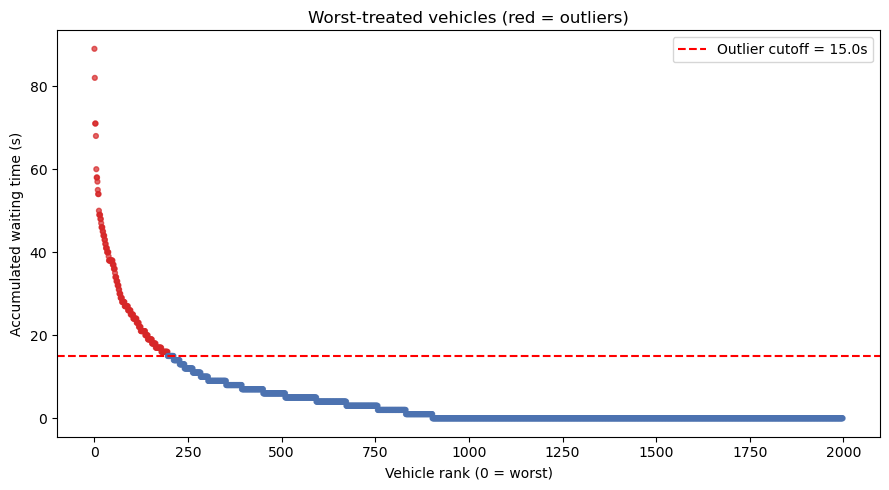

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/ziyodjanmirzataev/Desktop/LibSignalFork/vehicle_waiting_times_server.csv")
df = df[df["completed_trip"] == True].copy()
wait = df["accumulated_waiting_time_s"]
q1, q3 = wait.quantile([0.25, 0.75])
outlier_cut = q3 + 1.5 * (q3 - q1)
df["is_outlier"] = wait > outlier_cut

ranked = df.sort_values("accumulated_waiting_time_s", ascending=False).reset_index(drop=True)
colors = np.where(ranked["is_outlier"], "#D62728", "#4C72B0")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(ranked.index, ranked["accumulated_waiting_time_s"], c=colors, s=12, alpha=0.7)
ax.axhline(outlier_cut, color="red", linestyle="--", label=f"Outlier cutoff = {outlier_cut:.1f}s")
ax.set_xlabel("Vehicle rank (0 = worst)")
ax.set_ylabel("Accumulated waiting time (s)")
ax.set_title("Worst-treated vehicles (red = outliers)")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
CSV_PATH = "/Users/ziyodjanmirzataev/Desktop/LibSignalFork/extras/output/maxpressure/seed42_steps3600/vehicle_waiting_times.csv"


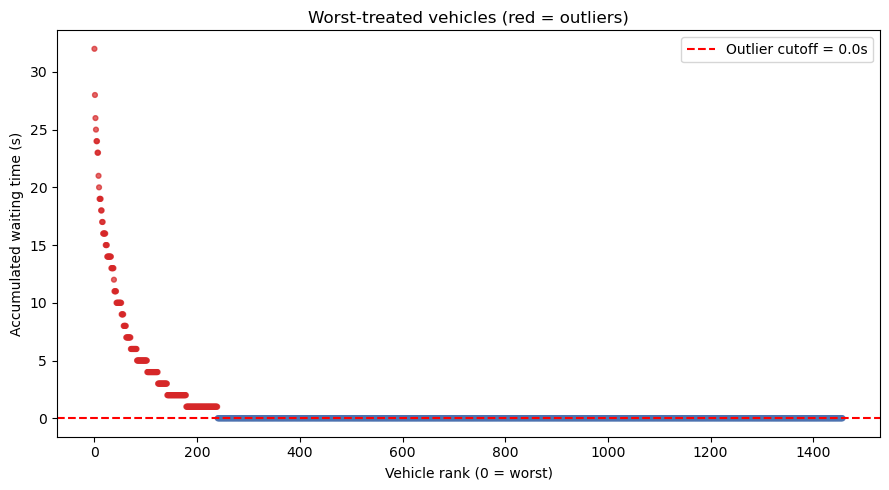

In [11]:

df = pd.read_csv("/Users/ziyodjanmirzataev/Desktop/LibSignalFork/extras/output/maxpressure/seed42_steps3600/vehicle_waiting_times.csv")
df = df[df["completed_trip"] == True].copy()
wait = df["accumulated_waiting_time_s"]
q1, q3 = wait.quantile([0.25, 0.75])
outlier_cut = q3 + 1.5 * (q3 - q1)
df["is_outlier"] = wait > outlier_cut

ranked = df.sort_values("accumulated_waiting_time_s", ascending=False).reset_index(drop=True)
colors = np.where(ranked["is_outlier"], "#D62728", "#4C72B0")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(ranked.index, ranked["accumulated_waiting_time_s"], c=colors, s=12, alpha=0.7)
ax.axhline(outlier_cut, color="red", linestyle="--", label=f"Outlier cutoff = {outlier_cut:.1f}s")
ax.set_xlabel("Vehicle rank (0 = worst)")
ax.set_ylabel("Accumulated waiting time (s)")
ax.set_title("Worst-treated vehicles (red = outliers)")
ax.legend()
plt.tight_layout()
plt.show()

## assumptions failed with the above graphs, need to find better way to record the data 
try it on next sit then

In [12]:
CSV_PATH = "/Users/ziyodjanmirzataev/Desktop/LibSignalFork/extras/output/maxpressure/sumo7x28/seed42_steps3600/vehicle_waiting_times.csv"


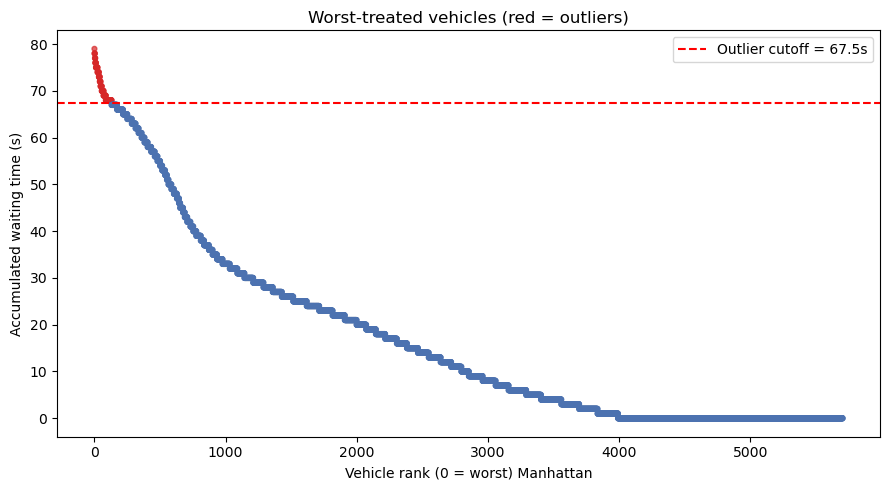

In [13]:
df = pd.read_csv("/Users/ziyodjanmirzataev/Desktop/LibSignalFork/extras/output/maxpressure/sumo7x28/seed42_steps3600/vehicle_waiting_times.csv")
df = df[df["completed_trip"] == True].copy()
wait = df["accumulated_waiting_time_s"]
q1, q3 = wait.quantile([0.25, 0.75])
outlier_cut = q3 + 1.5 * (q3 - q1)
df["is_outlier"] = wait > outlier_cut

ranked = df.sort_values("accumulated_waiting_time_s", ascending=False).reset_index(drop=True)
colors = np.where(ranked["is_outlier"], "#D62728", "#4C72B0")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(ranked.index, ranked["accumulated_waiting_time_s"], c=colors, s=12, alpha=0.7)
ax.axhline(outlier_cut, color="red", linestyle="--", label=f"Outlier cutoff = {outlier_cut:.1f}s")
ax.set_xlabel("Vehicle rank (0 = worst) Manhattan")
ax.set_ylabel("Accumulated waiting time (s)")
ax.set_title("Worst-treated vehicles (red = outliers)")
ax.legend()
plt.tight_layout()
plt.show()

# Big Problem: I see car disadvatage but can't prove and this is why: 
#### In standard SUMO/LibSignal configurations, the accumulated_waiting_time_s metric is only saved to the CSV when a vehicle successfully completes its trip and exits the map.

In [16]:
import pandas as pd

df = pd.read_csv(
    "../extras/output/maxpressure/sumo7x28/seed42_steps3600/vehicle_waiting_times.csv"
)

# Full picture (recommended for fairness plots)
waits = df["accumulated_waiting_time_s"]
print("max:", waits.max(), "p99:", waits.quantile(0.99))

# Only cars that never finished
stranded = df[df["completed_trip"] == False]
print("stranded max wait:", stranded["accumulated_waiting_time_s"].max())

max: 100.0 p99: 100.0
stranded max wait: 100.0


## What LibSignal saves vs what it hides

When you run a TSC agent (e.g. **MaxPressure**, DQN, CoLight) via `run.py`, LibSignal logs **network-level aggregates** — not per-vehicle fairness data.

### Typical saved metrics (trainer / `data/output_data/`)

| Metric | What it means |
|--------|----------------|
| **Average travel time** | Mean time **completed** trips spent in the network (driving + stopping), from enter → arrive |
| **Throughput** | How many vehicles **finished** their trip by sim end |
| **Queue** | Average count of nearly-stopped vehicles per intersection per step |
| **Delay (approx.)** | Lane-level `1 − v/v_max` — system congestion, not per-car wait |
| **Reward** | What the RL agent optimizes (often negative waiting count on **lanes**) |

MaxPressure only sees **lane vehicle counts** within ~200 m and picks the phase with highest pressure. It never sees individual vehicle IDs or “this car waited 40 minutes.”

### Same demand across model runs ✓

For the **same** `--network`, `--seed`, and `--test-steps`, LibSignal uses the **same** `*.rou.xml`: same cars, depart times, origins, destinations, and planned routes. Comparing agents is fair at the **demand** level — only signal control changes.

---

### <span style="color:red">**Problems these default logs hide (fairness blind spots)**</span>

<span style="color:red">**1. Non-finishers are dropped from the headline average**</span>  
`avg travel time` uses `world.vehicles` — only cars that **reached their destination**. Cars still on the road when the sim ends are **excluded**. On our 7×28 MaxPressure run: **5,705 finished** vs **6,481 still on the map** at 3600 s (~53% not counted).

<span style="color:red">**2. Aggregate metrics hide the long tail**</span>  
A low mean travel time or queue can coexist with **thousands of severely delayed** vehicles. The mean answers “how did finishers do?” not “who got hurt worst?”

<span style="color:red">**3. The policy never optimizes per-vehicle fairness**</span>  
RL/TSC rewards are lane sums or pressure. **No term penalizes** “one car waits 45 minutes while others pass.”

<span style="color:red">**4. SUMO’s `accumulated_waiting_time` caps at ~100 s**</span>  
`getAccumulatedWaitingTime()` is limited by `--waiting-time-memory=100`. Plots of that metric **flatten at 100 s** even when GUI / reality shows much longer stops.

<span style="color:red">**Bottom line:** default LibSignal reporting describes **system efficiency for successful trips**, not **equitable treatment of every vehicle**.</span>

In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adjust if your notebook cwd is result_analysis/
CSV = Path("../extras/output/maxpressure/sumo7x28/seed42_steps3600/vehicle_waiting_times.csv")
# Or absolute:
# CSV = Path("/Users/ziyodjanmirzataev/Desktop/LibSignalFork/extras/output/maxpressure/sumo7x28/seed42_steps3600/vehicle_waiting_times.csv")

df = pd.read_csv(CSV)
METRIC = "custom_wait_s"  # uncapped — do NOT use accumulated_waiting_time_s

assert METRIC in df.columns, "Missing custom_wait_s — re-run with updated extras/ on server"

w = df[METRIC]
print(f"n={len(df):,}  max={w.max():.0f}s  p95={w.quantile(0.95):.0f}s  p99={w.quantile(0.99):.0f}s")
print(df.groupby("trip_status")[METRIC].agg(["count", "median", "max"]))

n=12,186  max=2747s  p95=1964s  p99=2445s
               count  median     max
trip_status                         
completed       5705    92.0  2203.0
on_map_at_end   6481  1136.0  2747.0


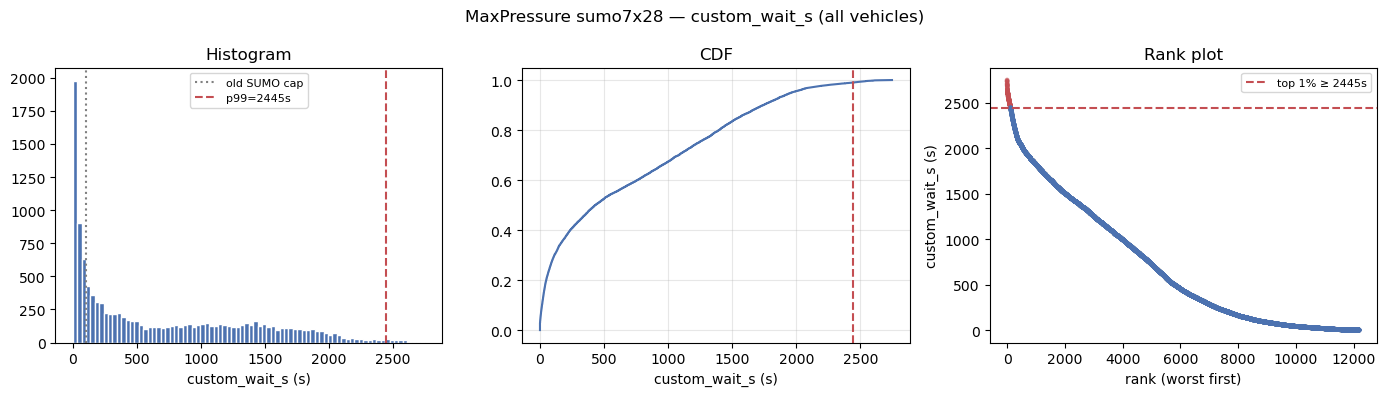

In [18]:
waits = df[METRIC].to_numpy()
waits_sorted = np.sort(waits)
n = len(waits)
p95, p99 = np.percentile(waits, [95, 99])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"MaxPressure sumo7x28 — {METRIC} (all vehicles)", fontsize=12)

# Histogram
axes[0].hist(waits, bins=80, color="#4C72B0", edgecolor="white")
axes[0].axvline(100, color="gray", linestyle=":", label="old SUMO cap")
axes[0].axvline(p99, color="#C44E52", linestyle="--", label=f"p99={p99:.0f}s")
axes[0].set_xlabel(f"{METRIC} (s)")
axes[0].set_title("Histogram")
axes[0].legend(fontsize=8)

# CDF
axes[1].plot(waits_sorted, np.arange(1, n + 1) / n, color="#4C72B0")
axes[1].axvline(p99, color="#C44E52", linestyle="--")
axes[1].set_xlabel(f"{METRIC} (s)")
axes[1].set_title("CDF")
axes[1].grid(alpha=0.3)

# Rank plot (worst first) — outliers in red
ranked = waits_sorted[::-1]
colors = np.where(ranked >= p99, "#C44E52", "#4C72B0")
axes[2].scatter(np.arange(1, n + 1), ranked, s=6, c=colors, alpha=0.6)
axes[2].axhline(p99, color="#C44E52", linestyle="--", label=f"top 1% ≥ {p99:.0f}s")
axes[2].set_xlabel("rank (worst first)")
axes[2].set_ylabel(f"{METRIC} (s)")
axes[2].set_title("Rank plot")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()  # renders in notebook — no file saved unless you add plt.savefig()

## How we obtained `custom_wait_s` — and what it reveals

**Tool:** `extras/run_vehicle_wait_logs.py`  
**Same sim as LibSignal:** MaxPressure, `sumo7x28`, seed 42, 3600 s  
**Output:** `extras/output/maxpressure/sumo7x28/seed42_steps3600/vehicle_waiting_times.csv`

### Method

Each simulation second, **before** `env.step()`:

- if `speed < 0.1 m/s` → `custom_wait[vehicle] += 1`
- no SUMO 100 s cap
- log **every** vehicle once: finished, removed, or still on map at end

**Plot `custom_wait_s`, not `accumulated_waiting_time_s`.**

### 7×28 MaxPressure results

| Group | Count | In LibSignal avg travel time? | `accumulated_waiting_time_s` max | `custom_wait_s` median | `custom_wait_s` max |
|-------|------:|------------------------------|----------------------------------:|-----------------------:|--------------------:|
| Completed | ~5,705 | Yes | 79 s | ~92 s | ~2,203 s |
| Still on map at 3600 s | ~6,481 | **No** | 100 s (cap) | **~1,136 s (~19 min)** | **~2,747 s (~46 min)** |
| **All vehicles** | ~12,186 | partial | 100 s (cap) | ~432 s | ~2,747 s |

### Why first plots looked too good

- SUMO wait read **after** trip end → finishers logged as **~0 s**
- `accumulated_waiting_time_s` **flatlines at 100 s**
- Only plotting **completed** trips hid **~53%** of cars still on the network

### What default RL / TSC reporting hides

- Mean travel time (~779 s here) is **finishers only** — not everyone who entered
- Throughput counts **completed** trips — stranded cars don't count
- Lane queue / pressure / reward = **aggregates** — no worst-off vehicle
- Papers rarely show **p99 / max wait** or **% never finishing**

### <span style="color:red">What `custom_wait_s` exposes</span>

<span style="color:red">System-level metrics can look acceptable while **half the fleet never finishes** and the worst cars sit nearly stopped for **20–45+ minutes** — a fairness failure invisible in standard LibSignal tables.</span>

```python
METRIC = "custom_wait_s"
df = pd.read_csv("../extras/output/maxpressure/sumo7x28/seed42_steps3600/vehicle_waiting_times.csv")
waits = df[METRIC]  # use ALL rows

Vehicles above threshold:
  >  30s: 10342  ( 84.9%)
  >  60s:  9476  ( 77.8%)
  > 100s:  8714  ( 71.5%)
  > 300s:  6887  ( 56.5%)
  > 600s:  5421  ( 44.5%)
  >1000s:  3973  ( 32.6%)
  >2000s:   540  (  4.4%)


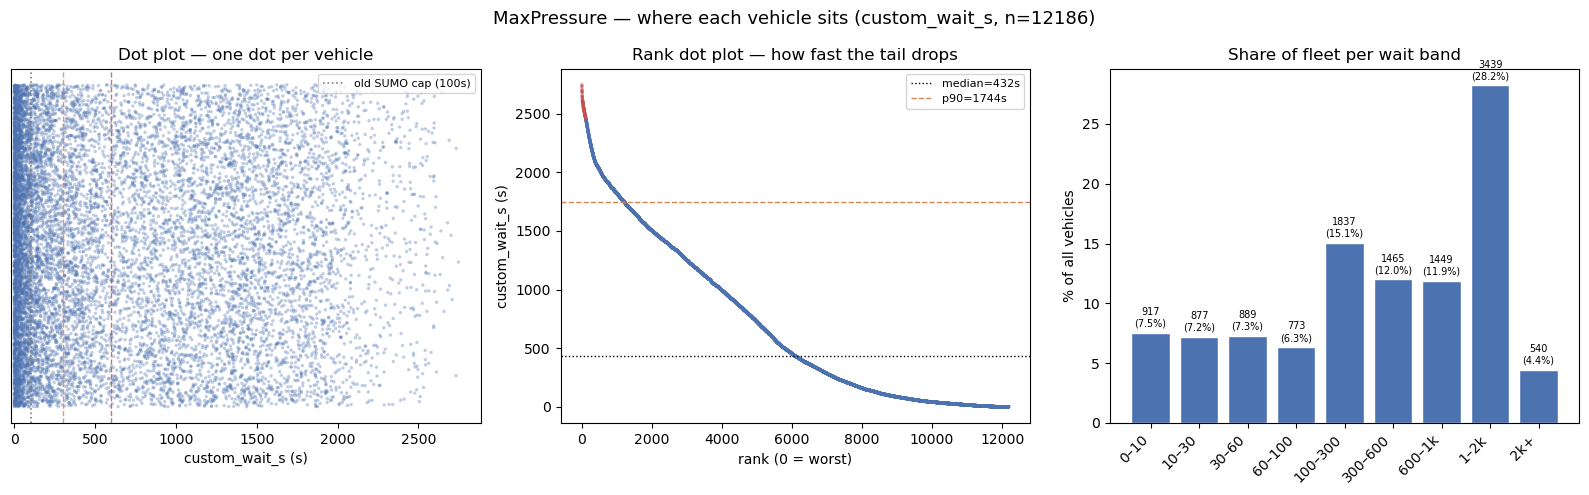

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV = Path("../extras/output/maxpressure/sumo7x28/seed42_steps3600/vehicle_waiting_times.csv")

df = pd.read_csv(CSV)
wait_col = "custom_wait_s" if "custom_wait_s" in df.columns else "accumulated_waiting_time_s"
w = df[wait_col].dropna().to_numpy()
n = len(w)

# --- how many above common cutoffs? ---
cuts = [0, 30, 60, 100, 300, 600, 1000, 2000]
print("Vehicles above threshold:")
for c in cuts[1:]:
    pct = 100 * (w > c).mean()
    print(f"  >{c:4d}s: {int((w > c).sum()):5d}  ({pct:5.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"MaxPressure — where each vehicle sits ({wait_col}, n={n})", fontsize=13)

# 1) DOT PLOT — every car, jittered vertically
rng = np.random.default_rng(0)
y_jitter = rng.uniform(-0.4, 0.4, size=n)
axes[0].scatter(w, y_jitter, s=6, alpha=0.35, c="#4C72B0", edgecolors="none")
axes[0].axvline(100, color="gray", ls=":", lw=1.2, label="old SUMO cap (100s)")
for thr, color in [(300, "#DD8452"), (600, "#C44E52")]:
    axes[0].axvline(thr, color=color, ls="--", lw=1, alpha=0.8)
axes[0].set_xlabel(f"{wait_col} (s)")
axes[0].set_yticks([])
axes[0].set_title("Dot plot — one dot per vehicle")
axes[0].set_xlim(left=-20)
axes[0].legend(loc="upper right", fontsize=8)

# 2) RANK DOT PLOT — sorted worst → best (easier to read density)
ranked = np.sort(w)[::-1]
colors = np.where(ranked >= np.percentile(w, 99), "#C44E52", "#4C72B0")
axes[1].scatter(np.arange(n), ranked, s=6, c=colors, alpha=0.5, edgecolors="none")
axes[1].axhline(np.percentile(w, 50), color="k", ls=":", lw=1, label=f"median={np.median(w):.0f}s")
axes[1].axhline(np.percentile(w, 90), color="#DD8452", ls="--", lw=1, label=f"p90={np.percentile(w, 90):.0f}s")
axes[1].set_xlabel("rank (0 = worst)")
axes[1].set_ylabel(f"{wait_col} (s)")
axes[1].set_title("Rank dot plot — how fast the tail drops")
axes[1].legend(fontsize=8)

# 3) BINS — % of fleet in each wait band (answers "many vs few")
bins = [0, 10, 30, 60, 100, 300, 600, 1000, 2000, np.inf]
labels = ["0–10", "10–30", "30–60", "60–100", "100–300", "300–600", "600–1k", "1–2k", "2k+"]
counts = pd.cut(w, bins=bins, labels=labels, right=False).value_counts().sort_index()
pct = 100 * counts / n
bars = axes[2].bar(range(len(counts)), pct, color="#4C72B0", edgecolor="white")
axes[2].set_xticks(range(len(counts)))
axes[2].set_xticklabels(labels, rotation=45, ha="right")
axes[2].set_ylabel("% of all vehicles")
axes[2].set_title("Share of fleet per wait band")
for i, (c, p) in enumerate(zip(counts, pct)):
    if p > 1:
        axes[2].text(i, p + 0.5, f"{int(c)}\n({p:.1f}%)", ha="center", fontsize=7)

plt.tight_layout()
plt.show()

for tmr (Saturday): 
1. confirm above stats with sumo 4x4 and cologne 1x1 
2. understand how custom travel time avg was taken out and calculated and why is it kept and not usually logged into files
3. understand the gui and start building realism axes 

In [21]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("../extras/output/maxpressure")  # from result_analysis/
RUN = "seed42_steps3600"
METRIC = "custom_wait_s"

NETWORKS = {
    "Cologne 1×1": "sumo1x1",
    "Grid 4×4": "sumo4x4",
    "Manhattan 7×28": "sumo7x28",
}

dfs = {}
for label, net in NETWORKS.items():
    path = ROOT / net / RUN / "vehicle_waiting_times.csv"
    df = pd.read_csv(path)
    assert METRIC in df.columns, f"{net}: missing {METRIC}"
    dfs[label] = df

In [22]:
rows = []
for label, df in dfs.items():
    w = df[METRIC]
    n = len(df)
    n_done = (df["trip_status"] == "completed").sum()
    n_stranded = (df["trip_status"] == "on_map_at_end").sum()
    rows.append({
        "Network": label,
        "Vehicles": n,
        "Completed": n_done,
        "Stranded": n_stranded,
        "Stranded %": round(100 * n_stranded / n, 1),
        "Mean (s)": round(w.mean(), 1),
        "Median (s)": round(w.median(), 1),
        "P95 (s)": round(w.quantile(0.95), 1),
        "P99 (s)": round(w.quantile(0.99), 1),
        "Max (s)": round(w.max(), 1),
    })

summary = pd.DataFrame(rows).set_index("Network")
summary

,Vehicles,Completed,Stranded,Stranded %,Mean (s),Median (s),P95 (s),P99 (s),Max (s)
Network,,,,,,,,,
Cologne 1×1,2014,1999,15,0.7,5.9,0.0,29.3,61.9,112.0
Grid 4×4,1473,1458,15,1.0,1.9,0.0,13.0,26.0,54.0
Manhattan 7×28,12186,5705,6481,53.2,695.9,432.0,1963.5,2445.0,2747.0


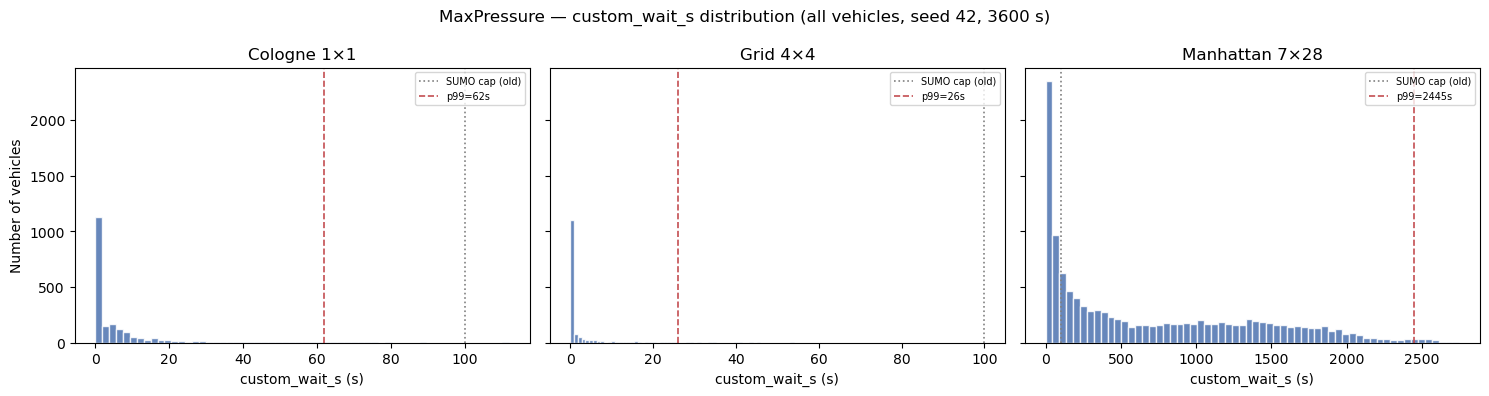

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle(f"MaxPressure — {METRIC} distribution (all vehicles, seed 42, 3600 s)", fontsize=12)

for ax, (label, df) in zip(axes, dfs.items()):
    w = df[METRIC]
    p99 = w.quantile(0.99)

    ax.hist(w, bins=60, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(100, color="gray", linestyle=":", linewidth=1.2, label="SUMO cap (old)")
    ax.axvline(p99, color="#C44E52", linestyle="--", linewidth=1.2, label=f"p99={p99:.0f}s")
    ax.set_title(label)
    ax.set_xlabel(f"{METRIC} (s)")
    ax.legend(fontsize=7, loc="upper right")

axes[0].set_ylabel("Number of vehicles")
plt.tight_layout()
plt.show()

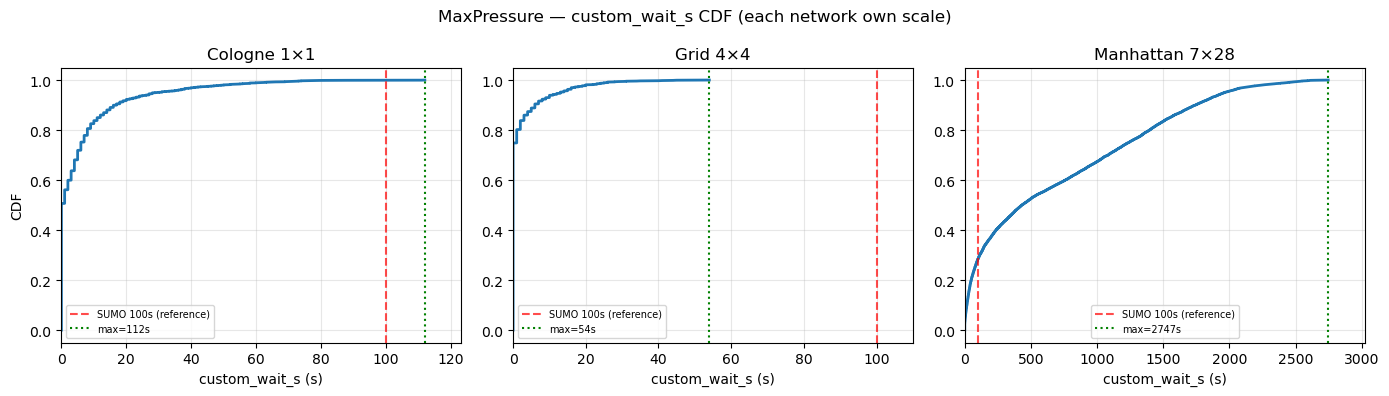

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"MaxPressure — {METRIC} CDF (each network own scale)")

for ax, (label, df) in zip(axes, dfs.items()):
    w = np.sort(df[METRIC].to_numpy())
    ax.plot(w, np.arange(1, len(w) + 1) / len(w), linewidth=2)
    ax.axvline(100, color="red", linestyle="--", alpha=0.7, label="SUMO 100s (reference)")
    ax.axvline(w.max(), color="green", linestyle=":", label=f"max={w.max():.0f}s")
    ax.set_title(label)
    ax.set_xlabel(f"{METRIC} (s)")
    ax.set_xlim(0, max(w.max() * 1.1, 110))  # each network zoomed to ITS max
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("CDF")
plt.tight_layout()
plt.show()

# Heterogeneous Vehicles Toggle — Build Summary

## What was done (high level)

1. **Toggle added to `configs/tsc/base.yml`** — new `hetero: false` flag in the `world:` section (same pattern as `physics_mode`).
2. **Sim configs updated** — `configs/sim/sumo{1x1,4x4,7x28}.cfg` got `flowFileHetero` + `heteroAdditional` keys pointing to hetero route/vType assets.
3. **`world/world_sumo.py`** — ~15 lines in `World.__init__`: when `hetero: true`, swaps the route file to `flowFileHetero` and passes `--additional-files vTypes_mixed.add.xml` to SUMO. When `false` (default), behavior is identical to the old baseline.
4. **vType definitions** — `data/raw_data/vTypes_mixed.add.xml` defines `car` (5 m, accel 2.6, maxSpeed 13.89) and `truck` (10 m, accel 1.4, maxSpeed 8.33). No agent code sees vType — all six controllers use lane counts/pressure unchanged.
5. **Hetero route files** — generated `*_hetero.rou.xml` for all three networks (80% car / 20% truck, same depart times and routes as baseline, only the vType mix changes).
6. **CSV logging** — `extras/run_vehicle_wait_logs.py` now includes a `vehicle_type` column and per-type wait stats in the meta JSON for car-vs-truck fairness analysis.
7. **Example configs** — `configs/tsc/maxpressure_hetero.yml` and `fixedtime_hetero.yml` override `hetero: true`.

## Where to turn the toggle on/off

The toggle lives in **`configs/tsc/base.yml`** under the `world:` section:

```yaml
world:
  hetero: false   # false = uniform baseline | true = mixed cars + trucks
```

For per-experiment overrides without editing `base.yml`, create a thin config that includes the agent config and sets `hetero: true` (see `configs/tsc/maxpressure_hetero.yml`).

## Usage example

```bash
# Baseline (hetero: false — default)
python run.py -a maxpressure -w sumo -n sumo4x4

# Hetero (via override config)
python run.py -a maxpressure_hetero -w sumo -n sumo4x4
```

Same seeds, same steps, same agents — only the vehicle mix changes. Compare ATT and `custom_wait_s` (p90, p99, %>300s) split by `vehicle_type`.


## Initial Experiment — MaxPressure on 4x4 (hetero vs baseline)

**Run:** `maxpressure_hetero` on `sumo4x4` (grid4x4), seed 42, 3600 steps, libsumo, deepnet (gpujobs).

### vType calibration fix

Initial run gave ATT 162.7 (+5% vs 155 baseline) — too small because `car` in `vTypes_mixed.add.xml` had `maxSpeed=13.89` and `accel=2.6`, **faster** than the baseline `pkw` (`maxSpeed=11.111`, `accel=2.0`). Fixed `car` to match `pkw` exactly so the only variable is the 20% truck mix.

### Results (fair ablation)

| Metric | Baseline (hetero=false) | Hetero (80% car / 20% truck) | Change |
|---|---|---|---|
| ATT (s) | 155.0 | 211.2 | +36% |
| Throughput | 1473 | 1453 | -20 veh |
| Queue | 0.066 | 0.554 | 8x |
| Delay | 0.153 | 0.234 | +53% |

The +36% ATT is driven by truck discharge bottlenecks: 20% trucks with 2x length, 0.7x accel, and 0.75x maxSpeed cause queue spillback that compounds across the dense 4x4 grid. Throughput barely drops (most vehicles still finish) — they just wait much longer. This confirms the toggle produces realistic capacity effects and is ready for the full experiment matrix.


# Hetero Toggle — DQN & PressLight on 4x4: Learning Curves & Comparison

Compares hetero (80% car / 20% truck) vs baseline (uniform vType) training curves and final ATT.
Hetero runs were trained from scratch on deepnet; baselines are existing grid4x4 reproductions.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import glob, os

COLS = ["model", "split", "episode", "travel_time", "col5", "reward", "queue", "delay", "throughput"]

def load_dtl(run_dir):
    """Load the longest _DTL.log from a run directory (avoids picking up aborted runs)."""
    files = glob.glob(os.path.join(run_dir, "logger", "*_DTL.log"))
    if not files:
        print(f"  WARNING: no DTL log in {run_dir}")
        return None
    f = max(files, key=lambda x: sum(1 for _ in open(x)))
    df = pd.read_csv(f, sep="\t", header=None, names=COLS)
    print(f"  Loaded {os.path.basename(f)}: {len(df)} rows")
    return df

RUNS = {
    "DQN baseline":        "../data/output_data/tsc/sumo_dqn/sumo4x4/dqn_grid4x4_seed42",
    "DQN hetero":          "../data/output_data/tsc/sumo_dqn_hetero/sumo4x4/hetero_test",
    "PressLight baseline": "../data/output_data/tsc/sumo_presslight/sumo4x4/grid_repro",
    "PressLight hetero":   "../data/output_data/tsc/sumo_presslight_hetero/sumo4x4/hetero_test",
    "CoLight baseline":    "../data/output_data/tsc/sumo_colight/sumo4x4/grid_repro",
    "CoLight hetero":      "../data/output_data/tsc/sumo_colight_hetero/sumo4x4/hetero_test",
}

dfs = {}
for label, path in RUNS.items():
    print(f"Loading {label}...")
    df = load_dtl(path)
    if df is not None:
        dfs[label] = df


Loading DQN baseline...
  Loaded 2026_06_27-09_30_14_DTL.log: 400 rows
Loading DQN hetero...
  Loaded 2026_07_04-18_24_39_DTL.log: 400 rows
Loading PressLight baseline...
  Loaded 2026_06_24-08_28_39_DTL.log: 400 rows
Loading PressLight hetero...
  Loaded 2026_07_04-18_24_47_DTL.log: 400 rows


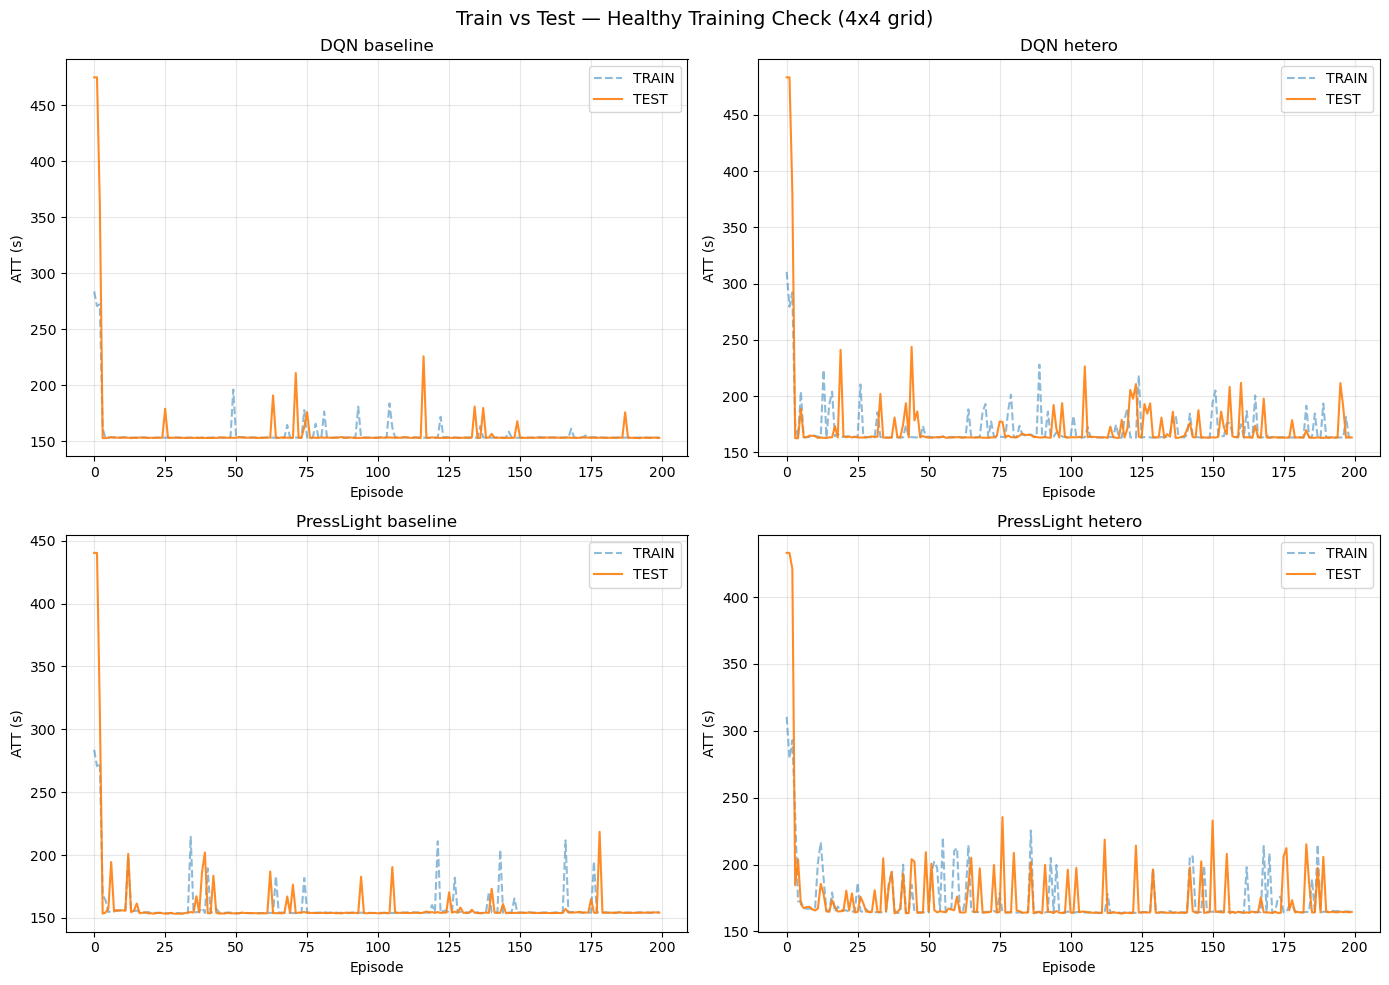

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plots = [
    ("DQN baseline",        axes[0][0]),
    ("DQN hetero",          axes[0][1]),
    ("PressLight baseline", axes[0][2]),
    ("PressLight hetero",   axes[1][0]),
    ("CoLight baseline",    axes[1][1]),
    ("CoLight hetero",      axes[1][2]),
]

for label, ax in plots:
    df = dfs.get(label)
    if df is None:
        ax.set_title(f"{label} (not found)")
        continue
    test = df[df["split"] == "TEST"]
    train = df[df["split"] == "TRAIN"]
    ax.plot(train["episode"], train["travel_time"], "--", alpha=0.5, label="TRAIN")
    ax.plot(test["episode"], test["travel_time"], "-", alpha=0.9, label="TEST")
    ax.set_title(label)
    ax.set_xlabel("Episode")
    ax.set_ylabel("ATT (s)")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Train vs Test — Healthy Training Check (4x4 grid)", fontsize=14)
plt.tight_layout()
plt.show()


In [7]:
rows = []
for label, df in dfs.items():
    test = df[df["split"] == "TEST"]
    best = test["travel_time"].min()
    final = test["travel_time"].iloc[-1]
    best_tp = test.loc[test["travel_time"].idxmin(), "throughput"]
    rows.append({
        "Run": label,
        "Best ATT (s)": round(best, 1),
        "Final ATT (s)": round(final, 1),
        "Throughput@best": int(best_tp),
        "Episodes": int(test["episode"].max()) + 1,
    })

comp = pd.DataFrame(rows)
print(comp.to_string(index=False))

print("\n--- Hetero vs Baseline Delta ---")
for agent in ["DQN", "PressLight", "CoLight"]:
    base = comp[comp["Run"].str.contains(f"{agent} baseline")]
    het = comp[comp["Run"].str.contains(f"{agent} hetero")]
    if len(base) and len(het):
        delta = het["Final ATT (s)"].values[0] - base["Final ATT (s)"].values[0]
        pct = 100 * delta / base["Final ATT (s)"].values[0]
        print(f"{agent}: {base['Final ATT (s)'].values[0]:.1f} -> {het['Final ATT (s)'].values[0]:.1f} ({pct:+.1f}%)")

print("\n--- vs MaxPressure reference ---")
print("MaxPressure baseline: 155.0s | MaxPressure hetero: 211.2s (+36.3%)")
print("RL agents (DQN, PressLight, CoLight) all converge to ~163-166s under hetero")
print("vs MaxPressure 211.2s — RL beats fixed policy by ~22% under vehicle heterogeneity.")


                Run  Best ATT (s)  Final ATT (s)  Throughput@best  Episodes
       DQN baseline         152.7          152.9             1457       200
         DQN hetero         162.6          163.2             1454       200
PressLight baseline         153.4          154.2             1456       200
  PressLight hetero         163.3          164.6             1454       200

--- Hetero vs Baseline Delta ---
DQN: 152.9 -> 163.2 (+6.7%)
PressLight: 154.2 -> 164.6 (+6.7%)

--- vs MaxPressure reference ---
MaxPressure baseline: 155.0s | MaxPressure hetero: 211.2s (+36.3%)
DQN hetero: 163.2s | PressLight hetero: 164.6s
RL agents beat MaxPressure hetero (211.2s) by ~22-23% — they learn to adapt to truck bottlenecks.
